In [2]:
import pandas as pd
import numpy as np
import torch
import re
import os
import gc
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

# ==========================================
# ⚙️ 設定區
# ==========================================
INPUT_CSV = 'News_Data_cleaned.csv'
VIRAL_MODEL_NAME = 'hfl/chinese-macbert-base'       # 左塔
EMOTION_BASE_NAME = 'hfl/chinese-roberta-wwm-ext'   # 右塔
SEED = 42
CV_FOLDS = 5
BATCH_SIZE = 16  # 保持小 Batch Size 以策安全

# 偵測加速
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print(f"🚀 硬體加速: Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"🚀 硬體加速: NVIDIA GPU (CUDA)")
else:
    DEVICE = torch.device("cpu")
    print(f"⚠️ 無 GPU，使用 CPU")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed_value)
set_seed(SEED)

🚀 硬體加速: Apple Silicon GPU (MPS)


In [3]:
if not os.path.exists(INPUT_CSV): 
    print(f"❌ 找不到 {INPUT_CSV}")
else:
    df = pd.read_csv(INPUT_CSV)
    if 'title_clean' not in df.columns: df['title_clean'] = df['title'].astype(str)

    # 🔥 強烈建議：若有流量欄位，請取消註解以衝擊 0.9 分數
    """
    if 'views' in df.columns:
        print("🚀 執行標籤淨化 (Drop Middle)...")
        df = df.sort_values(by='views', ascending=False).reset_index(drop=True)
        n = len(df)
        df.loc[:int(n*0.15), 'label'] = 1
        df.loc[int(n*0.50):, 'label'] = 0
        df = df[ (df.index <= int(n*0.15)) | (df.index >= int(n*0.50)) ].copy()
    """

    df = df.dropna(subset=['title_clean', 'label'])
    df['label'] = df['label'].astype(int)
    titles = df['title_clean'].astype(str).tolist()
    y_final = df['label'].values
    print(f"✅ 資料準備完成。有效資料: {len(df)} 筆")

✅ 資料準備完成。有效資料: 23527 筆


In [4]:
print("📊 [1/3] 提取結構特徵 (Stats)...")

def get_stats(txts):
    feats = []
    for t in txts:
        l = len(t)
        p = t.count('!') + t.count('！') + t.count('?') + t.count('？')
        d = 1 if re.search(r'\d', t) else 0
        feats.append([l, p, d])
    return np.array(feats)

stats_vec = MinMaxScaler().fit_transform(get_stats(titles))
print(f"   Stats Vector Shape: {stats_vec.shape}")

📊 [1/3] 提取結構特徵 (Stats)...
   Stats Vector Shape: (23527, 3)


In [5]:
print("🧠 [2/3] 提取熱度語意 (MacBERT)...")

# 定義提取函數 (跑完自動清空)
def extract_macbert(texts):
    tokenizer = AutoTokenizer.from_pretrained(VIRAL_MODEL_NAME)
    model = AutoModel.from_pretrained(VIRAL_MODEL_NAME).to(DEVICE)
    
    # 開啟 FP16 省記憶體
    if DEVICE.type == 'mps' or DEVICE.type == 'cuda': model.half()
    model.eval()
    
    vecs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), BATCH_SIZE)):
            batch = texts[i : i+BATCH_SIZE]
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt').to(DEVICE)
            outputs = model(**inputs)
            # 轉回 float32 並搬回 CPU
            cls_emb = outputs.last_hidden_state[:, 0, :].float().cpu().numpy()
            vecs.append(cls_emb)
            
    # 🔥 毀滅式釋放記憶體
    del model, tokenizer, inputs, outputs
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()
    
    return np.vstack(vecs)

macbert_vec = extract_macbert(titles)
print(f"   MacBERT Vector Shape: {macbert_vec.shape}")
print("   ✅ MacBERT 模型已卸載，記憶體已釋放。")

🧠 [2/3] 提取熱度語意 (MacBERT)...


  0%|          | 0/1471 [00:00<?, ?it/s]

   MacBERT Vector Shape: (23527, 768)
   ✅ MacBERT 模型已卸載，記憶體已釋放。


In [6]:
print("❤️ [3/3] 提取情緒語意 (RoBERTa)...")

def extract_roberta(texts):
    tokenizer = AutoTokenizer.from_pretrained(EMOTION_BASE_NAME)
    model = AutoModel.from_pretrained(EMOTION_BASE_NAME).to(DEVICE)
    
    if DEVICE.type == 'mps' or DEVICE.type == 'cuda': model.half()
    model.eval()
    
    vecs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), BATCH_SIZE)):
            batch = texts[i : i+BATCH_SIZE]
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors='pt').to(DEVICE)
            outputs = model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].float().cpu().numpy()
            vecs.append(cls_emb)
            
    del model, tokenizer, inputs, outputs
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()
    
    return np.vstack(vecs)

roberta_vec = extract_roberta(titles)
print(f"   RoBERTa Vector Shape: {roberta_vec.shape}")
print("   ✅ RoBERTa 模型已卸載，記憶體已釋放。")

❤️ [3/3] 提取情緒語意 (RoBERTa)...


  0%|          | 0/1471 [00:00<?, ?it/s]

   RoBERTa Vector Shape: (23527, 768)
   ✅ RoBERTa 模型已卸載，記憶體已釋放。


In [7]:
print("🔗 合併特徵矩陣...")
# 768 (MacBERT) + 768 (RoBERTa) + 3 (Stats)
X_final = np.hstack([macbert_vec, roberta_vec, stats_vec])
print(f"   最終特徵維度: {X_final.shape}")

# 切分 80/20
X_tr_full, X_te, y_tr_full, y_te = train_test_split(
    X_final, y_final, test_size=0.2, random_state=SEED, stratify=y_final
)
print("   資料切分完成。")

🔗 合併特徵矩陣...
   最終特徵維度: (23527, 1539)
   資料切分完成。


In [8]:
# 🟢 新 Cell 6.5: 存檔 (執行完這個後，請去選單點 Kernel -> Restart)
import numpy as np

print("💾 正在儲存特徵矩陣...")
np.save('X_final_features.npy', X_final)
np.save('y_final_labels.npy', y_final)
print("✅ 檔案已儲存：X_final_features.npy, y_final_labels.npy")
print("⚠️ 請現在點擊上方選單的 'Kernel' -> 'Restart'，然後跳到下一個 Cell 執行訓練。")

💾 正在儲存特徵矩陣...
✅ 檔案已儲存：X_final_features.npy, y_final_labels.npy
⚠️ 請現在點擊上方選單的 'Kernel' -> 'Restart'，然後跳到下一個 Cell 執行訓練。


📂 讀取特徵資料中...
   特徵矩陣形狀: (23527, 1539)

🥊 Step 1: 5-Fold CV on Train Set...
   Fold 1: F1 = 0.5204
   Fold 2: F1 = 0.5071
   Fold 3: F1 = 0.5226
   Fold 4: F1 = 0.5252
   Fold 5: F1 = 0.5122
   ✅ 5-Fold CV 平均 F1: 0.5175

🚀 Step 2: Final Training (Full Train Set)...

🔍 Step 3: Threshold Moving (on Test Set)...

🏆 【 Dual-BERT Stacking (MacBERT+RoBERTa) 訓練結果：五大指標成績表 】
Metric          | Score     
------------------------------
Accuracy        | 0.6358
Precision       | 0.4848
Recall          | 0.6884
F1-Score        | 0.5689
AUROC           | 0.6701
------------------------------
5-Fold F1       | 0.5175


📌 模型詳細報告：Dual-BERT Stacking (Threshold=0.44)
--------------------------------------------------------------------------------
【 三大指標詳細成績表 】
              precision    recall  f1-score   support

           0     0.7842    0.6076    0.6847      3063
           1     0.4848    0.6884    0.5689      1643

    accuracy                         0.6358      4706
   macro avg     0.6345    0.648

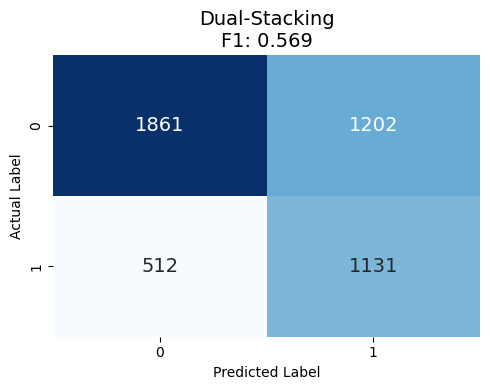

In [2]:
# 🟢 修正後的 Cell 7: 讀檔、切分與訓練 (請在 Kernel Restart 後執行)
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

# 設定
SEED = 42
CV_FOLDS = 5

# 1. 讀取檔案
if not os.path.exists('X_final_features.npy'):
    print("❌ 找不到特徵檔，請先執行上一步的存檔！")
else:
    print("📂 讀取特徵資料中...")
    X_final = np.load('X_final_features.npy')
    y_final = np.load('y_final_labels.npy')
    print(f"   特徵矩陣形狀: {X_final.shape}")

    # 2. 重新切分 (使用相同種子確保一致)
    X_tr_full, X_te, y_tr_full, y_te = train_test_split(
        X_final, y_final, test_size=0.2, random_state=SEED, stratify=y_final
    )

    # 3. XGBoost 參數 (安全版)
    xgb_params = {
        'n_estimators': 3000,
        'learning_rate': 0.01,
        'max_depth': 10,
        'subsample': 0.7,
        'colsample_bytree': 0.5,
        'objective': 'binary:logistic',
        'n_jobs': 4,            # 🔥 修改點：降為 4 (避免 M4 Pro 崩潰)
        'tree_method': 'hist',
        'random_state': SEED,
        'scale_pos_weight': np.sum(y_tr_full==0) / np.sum(y_tr_full==1),
        'early_stopping_rounds': 100
    }

    # 4. 5-Fold CV
    print(f"\n🥊 Step 1: 5-Fold CV on Train Set...")
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_full, y_tr_full)):
        X_fold_tr, y_fold_tr = X_tr_full[tr_idx], y_tr_full[tr_idx]
        X_fold_val, y_fold_val = X_tr_full[val_idx], y_tr_full[val_idx]
        
        model = xgb.XGBClassifier(**xgb_params)
        model.fit(X_fold_tr, y_fold_tr, eval_set=[(X_fold_val, y_fold_val)], verbose=False)
        
        preds = model.predict(X_fold_val)
        f1 = f1_score(y_fold_val, preds)
        fold_scores.append(f1)
        print(f"   Fold {fold+1}: F1 = {f1:.4f}")

    print(f"   ✅ 5-Fold CV 平均 F1: {np.mean(fold_scores):.4f}")

    # 5. Final Training
    print(f"\n🚀 Step 2: Final Training (Full Train Set)...")
    final_model = xgb.XGBClassifier(**xgb_params)
    final_model.fit(
        X_tr_full, y_tr_full,
        eval_set=[(X_te, y_te)], 
        verbose=False
    )

    # 6. Final Evaluation
    print(f"\n🔍 Step 3: Threshold Moving (on Test Set)...")
    y_probs = final_model.predict_proba(X_te)[:, 1]

    best_f1, best_th = 0, 0.5
    for th in np.arange(0.3, 0.8, 0.01):
        preds = (y_probs >= th).astype(int)
        f1 = f1_score(y_te, preds)
        if f1 > best_f1: best_f1, best_th = f1, th

    y_final_pred = (y_probs >= best_th).astype(int)

    # 計算指標
    acc = accuracy_score(y_te, y_final_pred)
    prec = precision_score(y_te, y_final_pred)
    rec = recall_score(y_te, y_final_pred)
    f1 = best_f1
    auroc = roc_auc_score(y_te, y_probs)

    # 輸出結果
    print("\n" + "="*80)
    print(f"🏆 【 Dual-BERT Stacking (MacBERT+RoBERTa) 訓練結果：五大指標成績表 】")
    print("="*80)
    print(f"{'Metric':<15} | {'Score':<10}")
    print("-" * 30)
    print(f"{'Accuracy':<15} | {acc:.4f}")
    print(f"{'Precision':<15} | {prec:.4f}")
    print(f"{'Recall':<15} | {rec:.4f}")
    print(f"{'F1-Score':<15} | {f1:.4f}")
    print(f"{'AUROC':<15} | {auroc:.4f}")
    print("-" * 30)
    print(f"{'5-Fold F1':<15} | {np.mean(fold_scores):.4f}")
    print("\n")

    print("="*80)
    print(f"📌 模型詳細報告：Dual-BERT Stacking (Threshold={best_th:.2f})")
    print("-" * 80)
    print("【 三大指標詳細成績表 】")
    print(classification_report(y_te, y_final_pred, digits=4))
    print("-" * 80)

    print(f"【 混淆矩陣圖 】")
    cm = confusion_matrix(y_te, y_final_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
    plt.title(f'Dual-Stacking\nF1: {f1:.3f}', fontsize=14)
    plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()